In [1]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv # API 키 관리를 위한 라이브러리
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic', 'Malgun Gothic', 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

load_dotenv()
data_api_key = os.getenv("DATA_API_KEY")

In [2]:
url = 'https://api.odcloud.kr/api/15081905/v1/uddi:f6c71932-d3a2-4a42-a990-abff225c72bc'
params = {
    "page": 1,
    "perPage": 4000,
    "returnType": 'json',
    "serviceKey": data_api_key
}

response = requests.get(url, params=params)
data = response.json()
df = pd.DataFrame(data['data'])
df.head()

,등록기준일,소재지(도로명),소재지(지번),소재지전화,업소명,업종명,연번
0,2025-06-09,세종특별자치시 조치원읍 조치원8길 34-6,세종특별자치시 조치원읍 정리 24-4,044 -865 -3356,세종식당,일반음식점,1
1,2025-06-09,"세종특별자치시 조치원읍 조치원로 3-1, 1층",세종특별자치시 조치원읍 원리 10-25 1층,044 -865 -1292,더비,일반음식점,2
2,2025-06-09,세종특별자치시 조치원읍 조치원8길 32,세종특별자치시 조치원읍 정리 24-7,044 -862 -1435,맛샘식당,일반음식점,3
3,2025-06-09,세종특별자치시 조치원읍 조치원8길 30,세종특별자치시 조치원읍 정리 24-1,044 -865 -3021,조치원집,일반음식점,4
4,2025-06-09,세종특별자치시 조치원읍 조치원6길 34,세종특별자치시 조치원읍 정리 29-2,044 -865 -0948,한방족발 곰나루,일반음식점,5


In [3]:
region_pattern = r"세종특별자치시\s+([가-힣]+(?:읍|면|동))\b"

address_for_region = (
    df["소재지(지번)"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(df["소재지(도로명)"])
)

df["지역"] = address_for_region.str.extract(region_pattern)[0]
df[["업소명", "소재지(도로명)", "소재지(지번)", "지역"]].head()

,업소명,소재지(도로명),소재지(지번),지역
0,세종식당,세종특별자치시 조치원읍 조치원8길 34-6,세종특별자치시 조치원읍 정리 24-4,조치원읍
1,더비,"세종특별자치시 조치원읍 조치원로 3-1, 1층",세종특별자치시 조치원읍 원리 10-25 1층,조치원읍
2,맛샘식당,세종특별자치시 조치원읍 조치원8길 32,세종특별자치시 조치원읍 정리 24-7,조치원읍
3,조치원집,세종특별자치시 조치원읍 조치원8길 30,세종특별자치시 조치원읍 정리 24-1,조치원읍
4,한방족발 곰나루,세종특별자치시 조치원읍 조치원6길 34,세종특별자치시 조치원읍 정리 29-2,조치원읍


In [4]:
missing_region = df[df["지역"].isna()][["업소명", "소재지(도로명)", "소재지(지번)"]]
print(f"지역 추출 실패: {len(missing_region)}건")

df = df["지역"].value_counts().sort_index()
sorted_df = df.sort_values(ascending=False)
sorted_df.head(10)


지역 추출 실패: 0건


지역
조치원읍    828
나성동     508
보람동     264
어진동     251
도담동     208
금남면     197
부강면     158
장군면     157
아름동     143
고운동     136
Name: count, dtype: int64

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

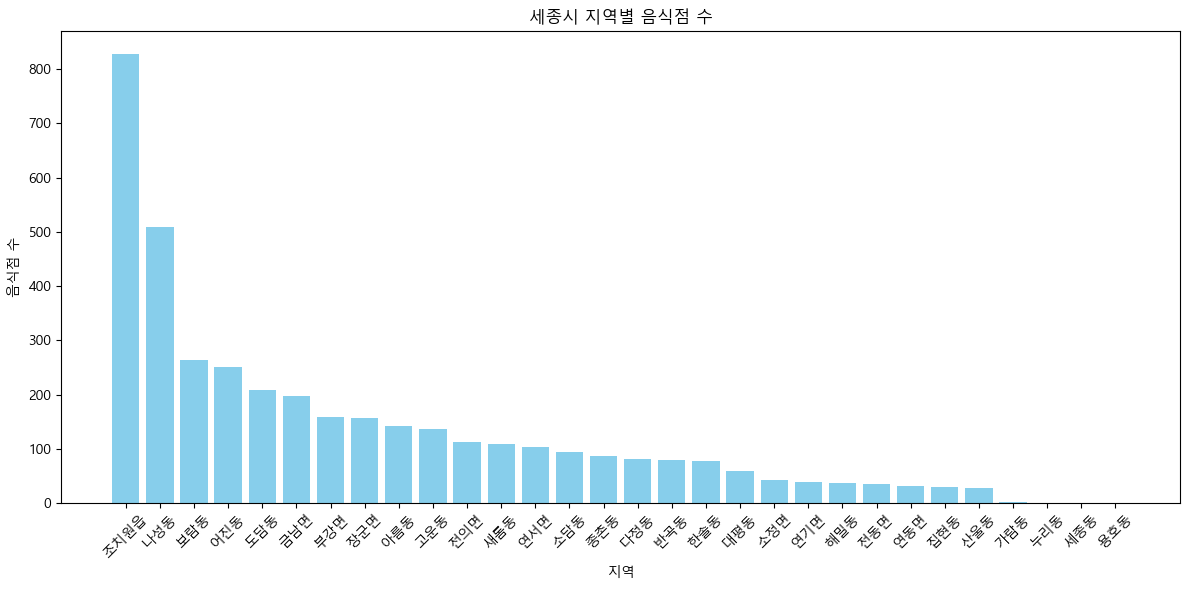

In [5]:
# 지역별 음식점 수 시각화
plt.figure(figsize=(12, 6))
plt.bar(sorted_df.index, sorted_df.values, color='skyblue')
plt.xlabel('지역')
plt.ylabel('음식점 수')
plt.title('세종시 지역별 음식점 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()